# Validación del Módulo Predictivo — Doble Logística

Evalúa la calidad de las predicciones por ventanas (T1, T2, T3, EOS) ejecutando
todo el pipeline en memoria y comparando contra la serie observada.

**BD:** pruebas (solo lectura). **No se persiste nada.**

In [1]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import sys, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter, MonthLocator
from IPython.display import display, HTML
from tqdm.notebook import tqdm
from datetime import timedelta
from contextlib import closing

from pipeline.ingesta import cargar_indices_desde_bd, cargar_clima_desde_bd
from pipeline.modulo_vpm import (
    preprocesar_indices_vpm,
    calcular_gpp_vpm,
    calcular_biomasa_y_rendimiento,
)
from pipeline.modulo_predictivo import (
    extender_serie_con_curva_parametrica,
    construir_serie_climatica_prediccion,
    obtener_climatologia,
    climatologia_disponible,
)
from utils.conexionDB import set_db_path, get_db_path, get_connection_raw
from config import GPKG_PRUEBAS_PATH, DURACION_CICLO


def cargar_indices_suavizados_ciclo(id_ciclo: int, id_parcela: int) -> tuple[pd.Series, pd.Series]:
    """
    Carga los índices EVI/LSWI suavizados (Whittaker) ya persistidos en BD
    para un ciclo específico. Evita re-suavizado inconsistente con el pipeline.

    Retorna
    -------
    tuple[pd.Series, pd.Series]
        (evi_suavizado, lswi_suavizado) con DatetimeIndex diario.
    """
    sql = """
        SELECT fecha, evi, lswi
        FROM indices_suavizados
        WHERE id_ciclo = ? AND id_parcela = ?
        ORDER BY fecha
    """
    with closing(get_connection_raw()) as conn:
        df = pd.read_sql(sql, conn, params=(id_ciclo, id_parcela), parse_dates=["fecha"])

    if df.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    df["fecha"] = pd.to_datetime(df["fecha"]).dt.normalize()
    df = df.drop_duplicates(subset="fecha").set_index("fecha").sort_index()

    evi = df["evi"].dropna()
    lswi = df["lswi"].dropna() if "lswi" in df.columns else pd.Series(dtype=float)

    return evi, lswi

2026-07-18 11:52:38.522 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 11:52:38.523 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 11:52:38.524 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 11:52:38.526 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 11:52:38.527 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 11:52:38.527 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 11:52:38.528 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 11:52:38.529 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-

In [2]:
# ── 0b. Conexión BD ──────────────────────────────────────────────────────────
set_db_path(GPKG_PRUEBAS_PATH)
print(f"BD activa: {get_db_path()}")
print(f"Climatología disponible: {climatologia_disponible()}")

BD activa: c:\Users\mayno\Desktop\SeminarioInvestigacion\segmentacion_clasificacion_estimacion_maiz_comayagua\notebooks\..\data\pipeline_pruebas.gpkg
Climatología disponible: True


---
### Herramientas de graficación

- `graficar_whittaker_sos()` de `utils/graficas.py` — gráfico interactivo con detección SOS.
- `graficar_prediccion_estatica()` — matplotlib estático exportable a PDF.

Ambas se usan más abajo en las secciones de validación.

In [3]:
# ── 0c. Función: graficar_prediccion_estatica ──────────────────────────────────
from utils.graficas import graficar_whittaker_sos

COLORES_GRAF = {"EVI": "#2ecc71", "LSWI": "#3498db"}


def graficar_prediccion_estatica(
    datos: dict,
    indices: list[str] | None = None,
    extrapolado: dict | None = None,
    validacion: dict | None = None,
    ventana_fecha: pd.Timestamp | None = None,
    ventana_nombre: str | None = None,
    sos_fecha: pd.Timestamp | None = None,
    eos_fecha: pd.Timestamp | None = None,
    titulo: str = "Series temporales",
    figsize: tuple = (14, 8),
) -> tuple[plt.Figure, list[plt.Axes]]:
    """
    Genera gráfico matplotlib estático (EVI/LSWI) con puntos crudos,
    línea suavizada, predicción punteada, validación en gris,
    y líneas verticales de ventanas.
    """
    if indices is None:
        indices = ["EVI", "LSWI"]
    n = len(indices)
    fig, axes = plt.subplots(n, 1, figsize=figsize, sharex=True, squeeze=False)
    axes = axes[:, 0]
    date_fmt = DateFormatter("%b\n%Y")
    locator = MonthLocator()

    for i, idx in enumerate(indices):
        ax = axes[i]
        color = COLORES_GRAF.get(idx, "#95a5a6")
        raw = datos.get("raw", {}).get(idx)
        smooth = datos.get("smoothed", {}).get(idx)

        if raw is not None and not raw.empty:
            ax.scatter(raw.index, raw.values, color=color, s=18,
                       alpha=0.5, zorder=3, label=f"{idx} crudo")
        if smooth is not None and not smooth.empty:
            ax.plot(smooth.index, smooth.values, color=color,
                    linewidth=2, zorder=4, label=f"{idx} suavizado")
        if validacion is not None:
            val = validacion.get(idx)
            if val is not None and not val.empty:
                ax.plot(val.index, val.values, color="#888888",
                        linewidth=2, zorder=3, label=f"{idx} observado")
        if extrapolado is not None:
            ext = extrapolado.get(idx)
            if ext is not None and not ext.empty:
                ax.plot(ext.index, ext.values, color=color,
                        linewidth=2, linestyle="--", zorder=4,
                        label=f"{idx} proyectado")

        if ventana_fecha is not None:
            etiq = f"{ventana_nombre or ''} {ventana_fecha.strftime('%d/%m/%Y')}"
            ax.axvline(x=ventana_fecha, color="#e74c3c", linewidth=1.5,
                       linestyle="--", alpha=0.8)
            ax.text(ventana_fecha, ax.get_ylim()[1], etiq,
                    color="#e74c3c", fontsize=9, ha="right", va="top")
        if sos_fecha is not None:
            ax.axvline(x=sos_fecha, color="#2ecc71", linewidth=2,
                       linestyle="--", alpha=0.8)
            ax.text(sos_fecha, ax.get_ylim()[1], f"SOS {sos_fecha.strftime('%d/%m/%Y')}",
                    color="#2ecc71", fontsize=9, ha="left", va="top")
        if eos_fecha is not None:
            ax.axvline(x=eos_fecha, color="#e74c3c", linewidth=2,
                       linestyle="--", alpha=0.8)
            ax.text(eos_fecha, ax.get_ylim()[1], f"EOS {eos_fecha.strftime('%d/%m/%Y')}",
                    color="#e74c3c", fontsize=9, ha="right", va="top")

        ax.set_ylabel(idx)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=9)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(date_fmt)

    axes[-1].set_xlabel("Fecha")
    fig.suptitle(titulo, fontsize=14, y=1.01)
    plt.tight_layout()
    return fig, axes

---
## A — Carga y selección de ciclos

In [4]:
# ── A1. Definir: cargar_ciclos_validos ──────────────────────────────────────────
def cargar_ciclos_validos() -> pd.DataFrame:
    """
    Carga ciclos finalizados con rendimiento, filtra duración <= 160 días.
    Retorna DataFrame en memoria. No persiste nada.
    """
    raw = pd.read_sql("""
        SELECT id_ciclo, id_parcela, temporada,
               sos, eos, t1, t2, t3,
               rendimiento, produccion_total,
               lswi_max, fecha_inicio
        FROM produccion_acumulada_ciclo
        WHERE estado_ciclo = 'finalizado'
          AND rendimiento IS NOT NULL
          AND sos IS NOT NULL AND eos IS NOT NULL
        ORDER BY id_ciclo
    """, get_connection_raw(), parse_dates=["sos", "eos", "t1", "t2", "t3", "fecha_inicio"])

    total = len(raw)
    raw["duracion"] = (raw["eos"] - raw["sos"]).dt.days
    mask = raw["duracion"] <= 160
    descartados = (~mask).sum()
    df = raw[mask].copy().reset_index(drop=True)

    print(f"Total ciclos finalizados con datos: {total}")
    print(f"Descartados por duración > 160 días: {descartados}")
    print(f"Ciclos aprobados: {len(df)}")
    print(f"Rango duraciones: {df['duracion'].min()} – {df['duracion'].max()} días")
    return df

In [5]:
# ── A2. Usar ──────────────────────────────────────────────────────────────────
df_ciclos = cargar_ciclos_validos()
display(df_ciclos[["id_ciclo", "id_parcela", "temporada", "sos", "eos", "duracion", "rendimiento"]].head(10))

Total ciclos finalizados con datos: 258
Descartados por duración > 160 días: 66
Ciclos aprobados: 192
Rango duraciones: 57 – 157 días


,id_ciclo,id_parcela,temporada,sos,eos,duracion,rendimiento
0,2615,0,primera,2020-05-06,2020-09-17,134,179.262083
1,2618,0,primera,2022-05-14,2022-08-09,87,62.828891
2,2619,0,postrera,2022-08-20,2022-12-11,113,46.413684
3,2620,0,postrera,2023-01-01,2023-04-17,106,145.322919
4,2622,0,postrera,2023-12-12,2024-05-06,146,135.516851
5,2623,0,primera,2024-05-24,2024-08-25,93,34.790906
6,2625,0,primera,2025-06-02,2025-10-09,129,49.385498
7,2626,0,postrera,2025-11-06,2026-03-11,125,102.328512
8,2627,1,primera,2020-05-14,2020-09-18,127,114.009322
9,2628,1,postrera,2020-09-28,2020-12-16,79,70.928496


---
## B — Predicción en memoria por ventanas

Para cada ciclo, ejecuta la cadena completa **extrapolación → GPP → NPP → Biomasa → Rendimiento**
sin persistir nada en BD.

In [6]:
# ── B1. Definir: prediccion_ventana_memoria ───────────────────────────────────
COLORES_VENTANA = {"T1": "#e67e22", "T2": "#9b59b6", "T3": "#e74c3c", "EOS": "#2ecc71"}


def prediccion_ventana_memoria(df_ciclos: pd.DataFrame) -> dict:
    """
    Ejecuta predicciones T1/T2/T3/EOS para todos los ciclos en memoria.

    Retorna
    -------
    dict con estructura:
        {
          id_ciclo: {
              "info": {...},  # metadatos del ciclo
              "curvas": {
                  "EVI": {  # serie observada completa para el ciclo
                      "observado": pd.Series,
                  },
                  "LSWI": {...},
              },
              "ventanas": {
                  "T1": {
                      "fecha": pd.Timestamp,
                      "curvas": {"EVI": pd.Series, "LSWI": pd.Series},  # serie extendida
                      "yield_qq_ha": float,
                      "yield_qq_parcela": float,
                      "parametros": dict | None,  # params doble logística
                  },
                  "T2": {...},
                  "T3": {...},
                  "EOS": {
                      "curvas": {"EVI": pd.Series, "LSWI": pd.Series},  # = observado
                      "yield_qq_ha": float,
                      "yield_qq_parcela": float,
                  },
              },
          },
          ...
        }
    """
    VENTANAS = ["T1", "T2", "T3", "EOS"]
    DIAS_DESDE_SOS = {"T1": 30, "T2": 60, "T3": 90, "EOS": DURACION_CICLO}
    resultados = {}

    # Pre-cargar clima y climatología
    clim_rad = obtener_climatologia("radiacion")
    clim_temp = obtener_climatologia("temperatura")

    for _, ciclo in tqdm(df_ciclos.iterrows(), total=len(df_ciclos), desc="Prediciendo ciclos"):
        id_ciclo = int(ciclo["id_ciclo"])
        id_parcela = int(ciclo["id_parcela"])
        sos = pd.Timestamp(ciclo["sos"])
        eos = pd.Timestamp(ciclo["eos"])
        fecha_inicio = pd.Timestamp(ciclo["fecha_inicio"]) if pd.notna(ciclo["fecha_inicio"]) else sos
        col = f"id_{id_parcela}"
        # Cargar índices suavizados YA persistidos en BD (indices_suavizados).
        # Esto garantiza consistencia con el pipeline: el pipeline guarda los
        # índices suavizados con Whittaker en esa tabla, y la predicción EOS
        # usa esos mismos valores. Re-suavizar aquí (sos:eos) produce valores
        # distintos porque Whittaker es sensible a los bordes de la serie.
        try:
            evi_obs_ciclo, lswi_obs_ciclo = cargar_indices_suavizados_ciclo(id_ciclo, id_parcela)
            # Filtrar al rango SOS:EOS del ciclo
            evi_obs_ciclo = evi_obs_ciclo.loc[sos:eos].dropna()
            lswi_obs_ciclo = lswi_obs_ciclo.loc[sos:eos].dropna()
        except Exception as e:
            print(f"  Ciclo {id_ciclo}: error cargando indices suavizados - {e}")
            continue

        if evi_obs_ciclo.empty:
            continue

        info = {
            "id_ciclo": id_ciclo,
            "id_parcela": id_parcela,
            "temporada": ciclo["temporada"],
            "sos": sos,
            "eos": eos,
            "rendimiento_final_qq_ha": float(ciclo["rendimiento"]),
            "produccion_final_qq": float(ciclo["produccion_total"]) if pd.notna(ciclo["produccion_total"]) else None,
        }

        ventanas_data = {}

        for v in VENTANAS:
            fecha_v = sos + pd.Timedelta(days=DIAS_DESDE_SOS[v])
            eos_ts = eos if v == "EOS" else sos + pd.Timedelta(days=DURACION_CICLO)

            if v == "EOS":
                evi_ext = evi_obs_ciclo
                lswi_ext = lswi_obs_ciclo
                params = None
            else:
                # Usar indices suavizados ya persistidos en BD (indices_suavizados)
                evi_obs_full, lswi_obs_full = cargar_indices_suavizados_ciclo(id_ciclo, id_parcela)
                if evi_obs_full.empty:
                    continue

                evi_obs = evi_obs_full.loc[sos:fecha_v].dropna()
                lswi_obs = lswi_obs_full.loc[sos:fecha_v].dropna()
                if evi_obs.empty or len(evi_obs) < 5:
                    continue

                try:
                    evi_ext, params_evi = extender_serie_con_curva_parametrica(
                        evi_obs, sos, eos_ts, ventana=v,
                    )
                    lswi_ext, params_lswi = extender_serie_con_curva_parametrica(
                        lswi_obs, sos, eos_ts, ventana=v,
                    )
                    params = {"EVI": params_evi, "LSWI": params_lswi}
                except Exception as e:
                    print(f"    ATENCION Ciclo {id_ciclo} {v}: error en extrapolacion - {e}")
                    continue
            col_df = col
            df_evi = pd.DataFrame({col_df: evi_ext})
            df_lswi = pd.DataFrame({col_df: lswi_ext})

            lswi_max_db = float(ciclo["lswi_max"]) if pd.notna(ciclo["lswi_max"]) else None
            lswi_max_serie = float(lswi_ext.max()) if not lswi_ext.empty else None
            if lswi_max_db is not None and lswi_max_serie is not None:
                lswi_max_usado = max(lswi_max_db, lswi_max_serie)
            else:
                lswi_max_usado = lswi_max_db if lswi_max_db is not None else lswi_max_serie

            df_w_scalar = (
                (1.0 + df_lswi) / (1.0 + lswi_max_usado)
                if lswi_max_usado else df_lswi.copy()
            )
            df_fpar = 1.0 * df_evi

            dfs_veg = {
                "EVI": df_evi, "LSWI": df_lswi,
                "FPAR": df_fpar, "W_scalar": df_w_scalar,
            }

            # ── Clima ───────────────────────────────────────────────────
            try:
                dfs_clima_raw = cargar_clima_desde_bd(
                    fecha_inicio=str(fecha_inicio.date()),
                    fecha_fin=str(eos_ts.date()),
                    ids_parcelas=[id_parcela],
                )
                temp_real = dfs_clima_raw["temperature-mean"][col_df].dropna()
                rad_real = dfs_clima_raw["solar-radiation-flux"][col_df].dropna()
            except Exception:
                temp_real = pd.Series(dtype=float)
                rad_real = pd.Series(dtype=float)

            fechas_ext = evi_ext.index
            serie_temp = construir_serie_climatica_prediccion(
                fecha_inicio, eos_ts, temp_real, clim_temp,
            ).reindex(fechas_ext)
            serie_rad = construir_serie_climatica_prediccion(
                fecha_inicio, eos_ts, rad_real, clim_rad,
            ).reindex(fechas_ext)

            dfs_clima = {
                "temperature-mean": pd.DataFrame({col_df: serie_temp}),
                "solar-radiation-flux": pd.DataFrame({col_df: serie_rad}),
            }

            # ── GPP → Yield ─────────────────────────────────────────────
            try:
                dfs_gpp = calcular_gpp_vpm(
                    dfs_vegetacion=dfs_veg, dfs_clima=dfs_clima,
                )
                gpp_recorte = dfs_gpp["GPP"].loc[sos:eos_ts]
                if gpp_recorte.empty:
                    continue
                res = calcular_biomasa_y_rendimiento(gpp_recorte)
                yield_tha = float(res["yield_final_tha"].iloc[0])
                yield_qq_ha = yield_tha * 22.0458
                area_row = pd.read_sql("SELECT area_ha FROM parcelas_vigentes WHERE id_parcela = ?",
                        get_connection_raw(), params=(id_parcela,))
                area = float(area_row["area_ha"].iloc[0]) if not area_row.empty else None
                yield_qq_parcela = yield_qq_ha * area if area and yield_qq_ha else None
            except Exception as e:
                print(f"    ⚠ Ciclo {id_ciclo} {v}: error en cadena VPM — {e}")
                continue

            ventanas_data[v] = {
                "fecha": fecha_v,
                "curvas": {"EVI": evi_ext, "LSWI": lswi_ext},
                "yield_qq_ha": yield_qq_ha,
                "yield_qq_parcela": yield_qq_parcela,
                "parametros": params,
            }

        if not ventanas_data:
            continue

        resultados[id_ciclo] = {
            "info": info,
            "curvas": {
                "EVI": {"observado": evi_obs_ciclo},
                "LSWI": {"observado": lswi_obs_ciclo},
            },
            "ventanas": ventanas_data,
        }

    return resultados

In [7]:
# ── B2. Usar ──────────────────────────────────────────────────────────────────
resultados = prediccion_ventana_memoria(df_ciclos)
print(f"\nCiclos procesados exitosamente: {len(resultados)}")

Prediciendo ciclos:   0%|          | 0/192 [00:00<?, ?it/s]

OK  Clima cargado desde BD: 152 fechas x 1 parcelas (2020-04-15 -> 2020-09-13).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 23.06 C
   - GPP Promedio diario del Maiz: 9.013 g C/m2/dia
   - GPP Maximo diario alcanzado: 21.99 g C/m2/dia
OK  Clima cargado desde BD: 152 fechas x 1 parcelas (2020-04-15 -> 2020-09-13).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 23.06 C
   - GPP Promedio diario del Maiz: 9.535 g C/m2/dia
   - GPP Maximo diario alcanzado: 21.69 g C/m2/dia
OK  Clima cargado desde BD: 152 fechas x 1 parcelas (2020-04-15 -> 2020-09-13).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 23.06 C
   - GPP Promedio diario del Maiz: 10.535 g C/m2/dia
   - GPP Maximo diario alcanzado:

[CURVA] NO se extiende — n_obs=61 R²=0.24606815460067366 (None si falló ajuste)
[CURVA] NO se extiende — n_obs=61 R²=0.12901568358173476 (None si falló ajuste)


OK  Clima cargado desde BD: 149 fechas x 1 parcelas (2024-05-06 -> 2024-10-01).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 23.38 C
   - GPP Promedio diario del Maiz: 4.604 g C/m2/dia
   - GPP Maximo diario alcanzado: 8.49 g C/m2/dia
OK  Clima cargado desde BD: 149 fechas x 1 parcelas (2024-05-06 -> 2024-10-01).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 23.38 C
   - GPP Promedio diario del Maiz: 3.345 g C/m2/dia
   - GPP Maximo diario alcanzado: 8.49 g C/m2/dia
OK  Clima cargado desde BD: 112 fechas x 1 parcelas (2024-05-06 -> 2024-08-25).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 94 dias.
   - Temperatura media registrada en la zona: 23.50 C
   - GPP Promedio diario del Maiz: 4.490 g C/m2/dia
   - GPP Maximo diario alcanzado: 8.4

[CURVA] NO se extiende — n_obs=91 R²=0.6617302281276402 (None si falló ajuste)


...

OK  Clima cargado desde BD: 147 fechas x 1 parcelas (2025-06-14 -> 2025-11-07).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 22.21 C
   - GPP Promedio diario del Maiz: 8.282 g C/m2/dia
   - GPP Maximo diario alcanzado: 16.49 g C/m2/dia
OK  Clima cargado desde BD: 147 fechas x 1 parcelas (2025-06-14 -> 2025-11-07).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 22.21 C
   - GPP Promedio diario del Maiz: 8.530 g C/m2/dia
   - GPP Maximo diario alcanzado: 16.49 g C/m2/dia
OK  Clima cargado desde BD: 104 fechas x 1 parcelas (2025-06-14 -> 2025-09-25).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 88 dias.
   - Temperatura media registrada en la zona: 22.55 C
   - GPP Promedio diario del Maiz: 10.694 g C/m2/dia
   - GPP Maximo diario alcanzado: 

[CURVA] NO se extiende — n_obs=61 R²=0.6314387147220386 (None si falló ajuste)


OK  Clima cargado desde BD: 169 fechas x 1 parcelas (2022-03-26 -> 2022-09-10).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 22.67 C
   - GPP Promedio diario del Maiz: 10.282 g C/m2/dia
   - GPP Maximo diario alcanzado: 20.05 g C/m2/dia
OK  Clima cargado desde BD: 165 fechas x 1 parcelas (2022-03-26 -> 2022-09-06).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 127 dias.
   - Temperatura media registrada en la zona: 22.67 C
   - GPP Promedio diario del Maiz: 10.122 g C/m2/dia
   - GPP Maximo diario alcanzado: 20.05 g C/m2/dia
OK  Clima cargado desde BD: 153 fechas x 1 parcelas (2023-04-26 -> 2023-09-25).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 23.67 C
   - GPP Promedio diario del Maiz: 5.747 g C/m2/dia
   - GPP Maximo diario alcanzado

[CURVA] NO se extiende — n_obs=61 R²=0.022344939223439608 (None si falló ajuste)


OK  Clima cargado desde BD: 144 fechas x 1 parcelas (2025-10-01 -> 2026-02-21).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 20.08 C
   - GPP Promedio diario del Maiz: 9.401 g C/m2/dia
   - GPP Maximo diario alcanzado: 15.68 g C/m2/dia
OK  Clima cargado desde BD: 144 fechas x 1 parcelas (2025-10-01 -> 2026-02-21).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 20.93 C
   - GPP Promedio diario del Maiz: 9.088 g C/m2/dia
   - GPP Maximo diario alcanzado: 15.18 g C/m2/dia
OK  Clima cargado desde BD: 144 fechas x 1 parcelas (2025-10-01 -> 2026-02-21).

OK Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   - Horizonte temporal continuo evaluado: 131 dias.
   - Temperatura media registrada en la zona: 20.08 C
   - GPP Promedio diario del Maiz: 4.442 g C/m2/dia
   - GPP Maximo diario alcanzado: 

---
### Diagnóstico: Ciclo 2626 — EVI T2 cae a negativo

Inspecciona los parámetros de la doble logística y la forma de la curva
para entender por qué la proyección T2 del EVI se desploma por debajo de 0.
La causa raíz es que `vmin_lb = -1` en `ajustar_curva_doble_logistica()`
para T2, permitiendo que `vmin` (la asíntota) quede negativa.


Parcela 0 — Ciclo #2626 (postrera)
SOS: 2025-11-06 → EOS: 2026-03-11
Duración: 125 días
Yield final: 102.3 qq/ha

── T2 ──────────────────────────────────────
  Yield estimado: 104.5 qq/ha
  Parámetros doble logística (EVI):
    vmin: -0.6928997044573313
    vmax: 0.9407777375730335
    S: 1.1592177335590747e-16
    mS: 0.07154196259916057
    A: 91.0
    mA: 0.06081066820928648
    r2: 0.9650583743032818


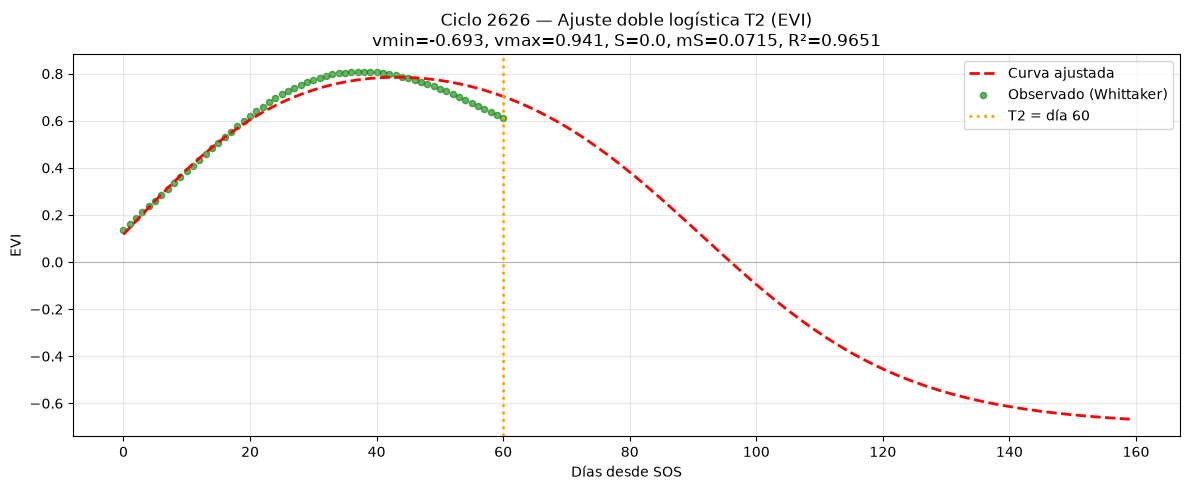

  vmin = -0.693 → la curva asintota a -0.693 al final del ciclo
  ⚠ vmin NEGATIVO → proyección cae bajo 0
  Causa raíz: vmin_lb = -1 en ajustar_curva_doble_logistica() para T2
  Fix: acotar vmin_lb = 0 en el fitting o pasar valor_valle explícito


In [8]:
# ── B3. Diagnosticar ciclo 2626 ───────────────────────────────────────────────
ID_DIAG = 2626

if ID_DIAG not in resultados:
    print(f"Ciclo {ID_DIAG} no está en resultados. Ejecuta B2 primero.")
else:
    data = resultados[ID_DIAG]
    info = data["info"]
    print(f"Parcela {info["id_parcela"]} — Ciclo #{ID_DIAG} ({info["temporada"]})")
    print(f"SOS: {info["sos"].date()} → EOS: {info["eos"].date()}")
    print(f"Duración: {(info["eos"] - info["sos"]).days} días")
    print(f"Yield final: {info["rendimiento_final_qq_ha"]:.1f} qq/ha\n")

    for v in ["T2"]:
        vd = data["ventanas"].get(v)
        if vd is None:
            print(f"  {v}: sin datos")
            continue
        params = vd.get("parametros")
        print(f"── {v} ──────────────────────────────────────")
        print(f"  Yield estimado: {vd["yield_qq_ha"]:.1f} qq/ha")
        if params and params.get("EVI"):
            p = params["EVI"]
            print(f"  Parámetros doble logística (EVI):")
            for k in ["vmin", "vmax", "S", "mS", "A", "mA", "r2"]:
                print(f"    {k}: {p.get(k, chr(8212))}")

            from pipeline.modulo_predictivo import _doble_logistica_t1

            dias_modelo = np.arange(0, 160, 1)
            curva = _doble_logistica_t1(dias_modelo, p["vmin"], p["vmax"], p["S"], p["mS"])

            obs_evi = data["curvas"]["EVI"]["observado"]
            sos = info["sos"]
            fecha_v = vd["fecha"]
            tramo = obs_evi.loc[sos:fecha_v]
            dias_obs = (tramo.index - sos).days.to_numpy(dtype=float)

            fig, ax = plt.subplots(figsize=(12, 5))
            ax.plot(dias_modelo, curva, "r--", linewidth=2, label="Curva ajustada")
            ax.scatter(dias_obs, tramo.values, color="green", s=20, alpha=0.6, label="Observado (Whittaker)")
            ax.axvline(x=(fecha_v - sos).days, color="orange", linewidth=2,
                       linestyle=":", label=f"T2 = día {(fecha_v - sos).days}")
            ax.axhline(y=0, color="gray", linewidth=0.8, alpha=0.5)
            ax.set_xlabel("Días desde SOS")
            ax.set_ylabel("EVI")
            ax.set_title(f"Ciclo {ID_DIAG} — Ajuste doble logística T2 (EVI)\n"
                         f"vmin={p["vmin"]:.3f}, vmax={p["vmax"]:.3f}, "
                         f"S={p["S"]:.1f}, mS={p["mS"]:.4f}, R²={p["r2"]:.4f}")
            ax.grid(True, alpha=0.3)
            ax.legend()
            plt.tight_layout()
            plt.show()

            print(f"  vmin = {p["vmin"]:.3f} → la curva asintota a {p["vmin"]:.3f} al final del ciclo")
            if p["vmin"] < 0:
                print("  ⚠ vmin NEGATIVO → proyección cae bajo 0")
                print("  Causa raíz: vmin_lb = -1 en ajustar_curva_doble_logistica() para T2")
                print("  Fix: acotar vmin_lb = 0 en el fitting o pasar valor_valle explícito")


---
## C — Inspección visual ciclo por ciclo

Widget interactivo para seleccionar un ciclo y ver sus curvas EVI/LSWI
con todas las ventanas de predicción superpuestas.

In [9]:
# ── C1. Definir: graficar_validacion_interactiva ───────────────────────────────
from ipywidgets import interact, Dropdown


def _figura_validacion_ciclo(
    id_ciclo: int,
    data: dict,
) -> plt.Figure:
    """Genera figura matplotlib para un ciclo (2 paneles: EVI, LSWI)."""
    info = data["info"]
    curvas = data["curvas"]
    ventanas = data["ventanas"]
    sos = info["sos"]
    eos = info["eos"]
    COLORS = {"EVI": "#2ecc71", "LSWI": "#3498db"}

    fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
    date_fmt = DateFormatter("%b\n%Y")
    locator = MonthLocator()

    for i, idx in enumerate(["EVI", "LSWI"]):
        ax = axes[i]
        color = COLORS[idx]

        obs = curvas[idx]["observado"]
        if obs is not None and not obs.empty:
            ax.plot(obs.index, obs.values, color=color, linewidth=2.5,
                    label=f"{idx} observado", zorder=4)

        for v_name, v_data in sorted(ventanas.items(),
                                     key=lambda x: ["T1", "T2", "T3", "EOS"].index(x[0])):
            ext = v_data["curvas"].get(idx)
            if ext is not None and not ext.empty:
                ext_plot = ext if v_name == "EOS" else ext.loc[v_data["fecha"]:]
                if not ext_plot.empty:
                    c = COLORES_VENTANA.get(v_name, "gray")
                    ls = ":" if v_name == "EOS" else "--"
                    lw = 1.5 if v_name == "EOS" else 1.2
                    ax.plot(ext_plot.index, ext_plot.values, color=c, linewidth=lw,
                            linestyle=ls, label=f"{idx} {v_name}", zorder=3)

        # Líneas verticales de ventanas
        for v_name, v_data in sorted(ventanas.items(),
                                     key=lambda x: ["T1", "T2", "T3", "EOS"].index(x[0])):
            c = COLORES_VENTANA.get(v_name, "gray")
            ax.axvline(x=v_data["fecha"], color=c, linewidth=2.5,
                       linestyle=":", alpha=0.5)
            ax.text(v_data["fecha"], ax.get_ylim()[1], f" {v_name}",
                    color=c, fontsize=8, ha="left", va="top", alpha=0.8)

        ax.set_ylabel(idx)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=8, ncol=4)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(date_fmt)

    yield_str = (f"Yield obs: {info['rendimiento_final_qq_ha']:.1f} qq/ha"
                 if info['rendimiento_final_qq_ha'] else "")
    yield_preds = ", ".join(
        f"{v}: {d['yield_qq_ha']:.1f}" for v, d in sorted(
            ventanas.items(), key=lambda x: ["T1", "T2", "T3", "EOS"].index(x[0]))
    )
    duracion = (info['eos'] - info['sos']).days
    fig.suptitle(
        f"Parcela {info['id_parcela']} — Ciclo #{id_ciclo} ({info['temporada']}) — {duracion} días\n"
        f"{yield_str}  |  Pred: {yield_preds} qq",
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    return fig


def graficar_validacion_interactiva(resultados: dict):
    """Widget interactivo para inspeccionar ciclos."""
    ids = sorted(resultados.keys())
    desc = {str(k): f"Ciclo #{k} — Parcela {resultados[k]['info']['id_parcela']}"
            for k in ids}

    @interact(Ciclo=Dropdown(options=desc, description="Ciclo"))
    def _render( Ciclo):
        id_c = int(Ciclo.split("#")[1].split(" ")[0]) if "#" in Ciclo else int(Ciclo)
        fig = _figura_validacion_ciclo(id_c, resultados[id_c])
        plt.show()
        plt.close(fig)

In [10]:
# ── C2. Usar ──────────────────────────────────────────────────────────────────
graficar_validacion_interactiva(resultados)

interactive(children=(Dropdown(description='Ciclo', options={'2615': 'Ciclo #2615 — Parcela 0', '2618': 'Ciclo…

---
## D — Métricas de ajuste de curvas

Para cada ciclo + ventana, compara el tramo extrapolado contra el observado
real (smoothed) en el rango [fecha_ventana, EOS] y calcula RMSE, MAE, MAPE, R².

In [11]:
# ── D1. Definir: calcular_metricas_curva ───────────────────────────────────────
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def calcular_metricas_curva(resultados: dict) -> pd.DataFrame:
    """
    Calcula RMSE, MAE, MAPE, R² por (id_ciclo, ventana, índice).
    Compara el tramo extrapolado vs observado en [fecha_ventana, EOS].
    """
    rows = []
    for id_ciclo, data in resultados.items():
        info = data["info"]
        eos = info["eos"]
        for v_name, v_data in data["ventanas"].items():
            if v_name == "EOS":
                continue  # EOS no tiene extrapolación
            fecha_v = v_data["fecha"]
            for idx in ["EVI", "LSWI"]:
                obs = data["curvas"][idx]["observado"]
                pred = v_data["curvas"].get(idx)
                if pred is None or pred.empty:
                    continue

                # Alinear ambas series al rango [fecha_ventana, eos]
                obs_tramo = obs.loc[fecha_v:eos].dropna()
                pred_tramo = pred.loc[fecha_v:eos].dropna()

                if obs_tramo.empty or pred_tramo.empty:
                    continue

                # Reindexar pred al index de obs para alineación perfecta
                comunes = obs_tramo.index.intersection(pred_tramo.index)
                if len(comunes) < 3:
                    continue
                y_true = obs_tramo.loc[comunes].values
                y_pred = pred_tramo.loc[comunes].values

                rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
                mae = float(mean_absolute_error(y_true, y_pred))
                mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10))) * 100)
                r2 = float(r2_score(y_true, y_pred))

                rows.append({
                    "id_ciclo": id_ciclo,
                    "id_parcela": info["id_parcela"],
                    "ventana": v_name,
                    "indice": idx,
                    "n_puntos": len(comunes),
                    "rmse": round(rmse, 4),
                    "mae": round(mae, 4),
                    "mape": round(mape, 2),
                    "r2": round(r2, 4),
                })

    return pd.DataFrame(rows)

In [12]:
# ── D2. Usar ──────────────────────────────────────────────────────────────────
df_metricas = calcular_metricas_curva(resultados)
print(f"Total filas métricas: {len(df_metricas)}")
display(df_metricas.head(12))

Total filas métricas: 972


,id_ciclo,id_parcela,ventana,indice,n_puntos,rmse,mae,mape,r2
0,2615,0,T1,EVI,101,0.2117,0.1432,34.39,-3.0863
1,2615,0,T1,LSWI,101,0.2936,0.2288,170.52,-1.7993
2,2615,0,T2,EVI,71,0.1885,0.1434,35.08,-3.8680
3,2615,0,T2,LSWI,71,0.2278,0.1932,157.17,-0.9041
4,2615,0,T3,EVI,41,0.1158,0.1066,26.47,-27.6633
5,2615,0,T3,LSWI,41,0.2035,0.1708,177.06,-8.3414
6,2618,0,T1,EVI,58,0.1545,0.1122,75.99,-0.1162
7,2618,0,T1,LSWI,58,0.1687,0.1194,135.07,0.1151
8,2618,0,T2,EVI,28,0.1169,0.1100,80.70,-0.1908
9,2618,0,T2,LSWI,28,0.1305,0.1208,130.60,0.1269


In [13]:
# ── D3. Definir: imprimir_reporte_metricas ─────────────────────────────────────
def imprimir_reporte_metricas(df: pd.DataFrame):
    """Imprime reporte detallado de métricas por ventana e índice."""
    print("=" * 72)
    print("REPORTE DE MÉTRICAS — PREDICCIÓN VS OBSERVADO")
    print("=" * 72)

    for idx in ["EVI", "LSWI"]:
        sub = df[df["indice"] == idx]
        if sub.empty:
            continue
        print(f"\n── {idx} ──────────────────────────────────────────────────")
        print(f"{'Ventana':<8} {'n':>5} {'RMSE':>8} {'MAE':>8} {'MAPE':>8} {'R²':>8}")
        print("-" * 45)
        for v in ["T1", "T2", "T3"]:
            g = sub[sub["ventana"] == v]
            if g.empty:
                continue
            print(f"{v:<8} {len(g):>5} {g['rmse'].mean():>8.4f} {g['mae'].mean():>8.4f} "
                  f"{g['mape'].mean():>7.1f}% {g['r2'].mean():>8.4f}")

    print("\n" + "=" * 72)
    print("TOP 5 PEORES CICLOS POR RMSE (EVI)")
    print("=" * 72)
    evi = df[df["indice"] == "EVI"]
    peores_ids = evi.groupby("id_ciclo")["rmse"].mean().nlargest(5).index
    peores = evi[evi["id_ciclo"].isin(peores_ids)]
    print(f"{'id_ciclo':>8} {'ventana':<8} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
    print("-" * 36)
    for _, r in peores.iterrows():
        print(f"{r['id_ciclo']:>8} {r['ventana']:<8} {r['rmse']:>8.4f} {r['mae']:>8.4f} {r['r2']:>8.4f}")

In [14]:
# ── D4. Usar ──────────────────────────────────────────────────────────────────
imprimir_reporte_metricas(df_metricas)

REPORTE DE MÉTRICAS — PREDICCIÓN VS OBSERVADO

── EVI ──────────────────────────────────────────────────
Ventana      n     RMSE      MAE     MAPE       R²
---------------------------------------------
T1         180   0.1002   0.0803    65.0%  -1.1405
T2         167   0.0968   0.0798    36.8%  -5.8799
T3         140   0.0543   0.0445    19.6% -21.3251

── LSWI ──────────────────────────────────────────────────
Ventana      n     RMSE      MAE     MAPE       R²
---------------------------------------------
T1         182   0.1344   0.1077   364.8%  -1.4438
T2         161   0.1198   0.0988   390.4% -18.1148
T3         142   0.0759   0.0617   314.8% -67.2182

TOP 5 PEORES CICLOS POR RMSE (EVI)
id_ciclo ventana      RMSE      MAE       R²
------------------------------------
    2653 T1         0.1848   0.1486  -1.7310
    2653 T2         0.0928   0.0829   0.5022
    2653 T3         0.6134   0.5319 -19.6238
    2662 T1         0.2304   0.1989  -1.2201
    2669 T1         0.1030   0.0779  

---
## E — Análisis de convergencia de rendimiento

Evalúa cómo evoluciona el rendimiento estimado en T1→T2→T3→EOS y si converge
al rendimiento final medido.

In [15]:
# ── E1. Definir: calcular_convergencia_rendimiento ─────────────────────────────
def calcular_convergencia_rendimiento(resultados: dict) -> pd.DataFrame:
    """
    Construye DataFrame con yield estimado por ventana y error vs final.
    """
    rows = []
    for id_ciclo, data in resultados.items():
        info = data["info"]
        final = info["rendimiento_final_qq_ha"]
        row = {
            "id_ciclo": id_ciclo,
            "id_parcela": info["id_parcela"],
            "temporada": info["temporada"],
            "yield_final_qq_ha": final,
        }
        for v in ["T1", "T2", "T3", "EOS"]:
            vd = data["ventanas"].get(v)
            if vd is not None:
                y = vd["yield_qq_ha"]
                row[f"yield_{v.lower()}_qq_ha"] = y
                row[f"error_{v.lower()}_qq_ha"] = y - final if final and y else None
                row[f"error_pct_{v.lower()}"] = ((y - final) / final * 100) if final and y else None
            else:
                row[f"yield_{v.lower()}_qq_ha"] = None
                row[f"error_{v.lower()}_qq_ha"] = None
                row[f"error_pct_{v.lower()}"] = None
        rows.append(row)
    return pd.DataFrame(rows)

In [16]:
# ── E2. Usar ──────────────────────────────────────────────────────────────────
df_conv = calcular_convergencia_rendimiento(resultados)
print(f"Total ciclos con convergencia: {len(df_conv)}")
display(df_conv.head(10))

Total ciclos con convergencia: 192


,id_ciclo,id_parcela,temporada,yield_final_qq_ha,yield_t1_qq_ha,error_t1_qq_ha,error_pct_t1,yield_t2_qq_ha,error_t2_qq_ha,error_pct_t2,yield_t3_qq_ha,error_t3_qq_ha,error_pct_t3,yield_eos_qq_ha,error_eos_qq_ha,error_pct_eos
0,2615,0,primera,179.262083,176.429211,-2.832872,-1.580297,186.635297,7.373213,4.113091,206.206248,26.944165,15.030599,227.812231,48.550148,27.083333
1,2618,0,primera,62.828891,143.862024,81.033133,128.974317,106.997755,44.168864,70.300244,91.895283,29.066392,46.262780,94.317207,31.488316,50.117574
2,2619,0,postrera,46.413684,131.139091,84.725407,182.544023,110.119179,63.705494,137.255844,85.249521,38.835836,83.673246,81.437825,35.024140,75.460806
3,2620,0,postrera,145.322919,221.788164,76.465245,52.617471,185.395908,40.072989,27.575133,203.165803,57.842884,39.803002,184.681210,39.358291,27.083333
4,2622,0,postrera,135.516851,199.369897,63.853046,47.118159,159.182441,23.665590,17.463209,170.400890,34.884038,25.741477,172.219332,36.702481,27.083333
5,2623,0,primera,34.790906,95.928343,61.137437,175.728210,90.117377,55.326471,159.025669,65.485445,30.694539,88.225753,63.062914,28.272008,81.262637
6,2625,0,primera,49.385498,123.176421,73.790923,149.418200,51.380898,1.995399,4.040456,NaN,NaN,NaN,75.513464,26.127966,52.906150
7,2626,0,postrera,102.328512,138.120203,35.791691,34.977242,104.463288,2.134777,2.086199,135.498819,33.170307,32.415508,130.042484,27.713972,27.083333
8,2627,1,primera,114.009322,NaN,NaN,NaN,148.001527,33.992206,29.815286,160.191883,46.182562,40.507707,160.355098,46.345776,40.650866
9,2628,1,postrera,70.928496,184.991459,114.062963,160.814017,NaN,NaN,NaN,135.518006,64.589509,91.062849,100.819513,29.891017,42.142466


In [17]:
# ── E3. Scatter T1/T2/T3/EOS vs rendimiento final ───────────────────────────
def graficar_scatter_convergencia(df_conv: pd.DataFrame):
    """Scatter plots: yield estimado en cada ventana vs yield final."""
    ventanas = ["T1", "T2", "T3", "EOS"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i, v in enumerate(ventanas):
        ax = axes[i]
        col_y = f"yield_{v.lower()}_qq_ha"
        sub = df_conv.dropna(subset=[col_y, "yield_final_qq_ha"])
        if sub.empty:
            ax.set_title(f"{v} — sin datos")
            continue

        for temp, color in [("primera", "#2ecc71"), ("postrera", "#e67e22")]:
            g = sub[sub["temporada"] == temp]
            if not g.empty:
                ax.scatter(g["yield_final_qq_ha"], g[col_y],
                           color=color, alpha=0.6, s=30, label=temp)

        # Línea 1:1
        lims = [
            min(sub["yield_final_qq_ha"].min(), sub[col_y].min()),
            max(sub["yield_final_qq_ha"].max(), sub[col_y].max()),
        ]
        ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="1:1")
        ax.set_xlabel("Yield final (qq/ha)")
        ax.set_ylabel(f"Yield {v} (qq/ha)")
        ax.set_title(f"{v} vs final")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig("scatter_convergencia_rendimiento.pdf", format="pdf", bbox_inches="tight")
    plt.show()

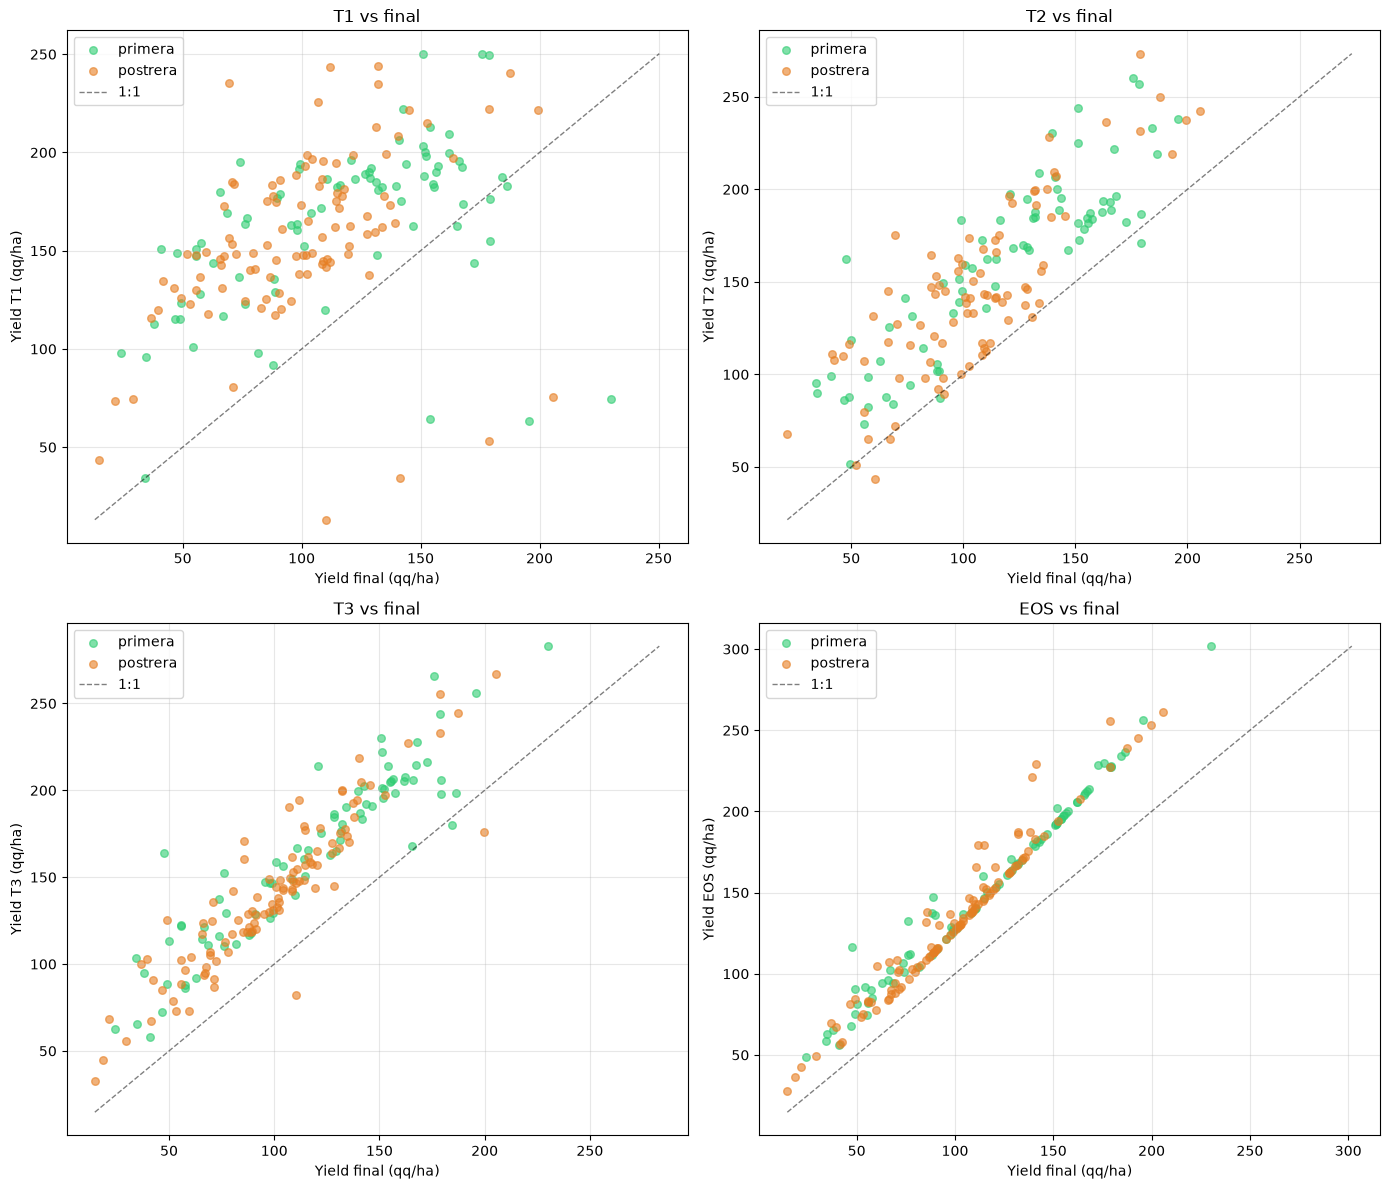

In [18]:
# ── E4. Usar scatter ─────────────────────────────────────────────────────────
graficar_scatter_convergencia(df_conv)

In [19]:
# ── E5. Definir: fan chart por parcela ────────────────────────────────────────
from ipywidgets import Dropdown, interact


def graficar_fan_chart_parcela(df_conv: pd.DataFrame):
    """
    Fan chart interactivo: para una parcela, muestra la evolución T1→T2→T3→EOS
    de cada ciclo como una línea, más el yield final como línea horizontal.
    """
    parcelas = sorted(df_conv["id_parcela"].unique())
    opts = {str(p): f"Parcela {p}" for p in parcelas}

    @interact(Parcela=Dropdown(options=opts, description="Parcela"))
    def _plot(Parcela):
        pid = int(Parcela)
        sub = df_conv[df_conv["id_parcela"] == pid].sort_values("id_ciclo")
        if sub.empty:
            print("Sin datos")
            return

        fig, ax = plt.subplots(figsize=(12, 6))
        ventanas = ["T1", "T2", "T3", "EOS"]
        x_pos = list(range(len(ventanas)))

        for _, row in sub.iterrows():
            vals = [row.get(f"yield_{v.lower()}_qq_ha") for v in ventanas]
            if any(v is None for v in vals):
                continue
            ax.plot(x_pos, vals, "o-", alpha=0.7, linewidth=1.5,
                    label=f"Ciclo #{row['id_ciclo']}")
            ax.axhline(y=row["yield_final_qq_ha"], color="gray", linewidth=0.8,
                       linestyle=":", alpha=0.5)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(ventanas)
        ax.set_ylabel("Yield (qq/ha)")
        ax.set_title(f"Convergencia de rendimiento — Parcela {pid}")
        ax.grid(True, alpha=0.3)
        if len(sub) <= 12:
            ax.legend(fontsize=8, loc="best")
        plt.tight_layout()
        plt.show()

In [20]:
# ── E6. Usar fan chart parcela ───────────────────────────────────────────────
graficar_fan_chart_parcela(df_conv)

interactive(children=(Dropdown(description='Parcela', options={'0': 'Parcela 0', '1': 'Parcela 1', '2': 'Parce…

In [21]:
# ── E7. Definir: fan chart agregado ───────────────────────────────────────────
def graficar_fan_chart_agregado(df_conv: pd.DataFrame):
    """
    Fan chart agregado: todas las curvas superpuestas + promedio ± 1 std.
    """
    ventanas = ["T1", "T2", "T3", "EOS"]
    x_pos = list(range(len(ventanas)))

    matriz = []
    for _, row in df_conv.iterrows():
        vals = [row.get(f"yield_{v.lower()}_qq_ha") for v in ventanas]
        if any(v is None for v in vals):
            continue
        matriz.append(vals)

    if not matriz:
        print("Sin datos para fan chart agregado")
        return

    matriz = np.array(matriz)
    mean = matriz.mean(axis=0)
    std = matriz.std(axis=0)

    fig, ax = plt.subplots(figsize=(14, 7))

    # Curvas individuales (con alpha bajo)
    for vals in matriz:
        ax.plot(x_pos, vals, color="gray", alpha=0.15, linewidth=0.8)

    # Promedio ± 1 std
    ax.fill_between(x_pos, mean - std, mean + std,
                    alpha=0.25, color="#3498db", label="±1 std")
    ax.plot(x_pos, mean, "o-", color="#2c3e50", linewidth=2.5,
            label="Promedio")

    # Yield final promedio como referencia
    mean_final = df_conv["yield_final_qq_ha"].mean()
    ax.axhline(y=mean_final, color="#e74c3c", linewidth=1.5,
               linestyle="--", label=f"Yield final promedio ({mean_final:.1f})")

    ax.set_xticks(x_pos)
    ax.set_xticklabels(ventanas)
    ax.set_ylabel("Yield (qq/ha)")
    ax.set_title("Fan chart agregado — Convergencia de rendimiento")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig("fan_chart_convergencia.pdf", format="pdf", bbox_inches="tight")
    plt.show()

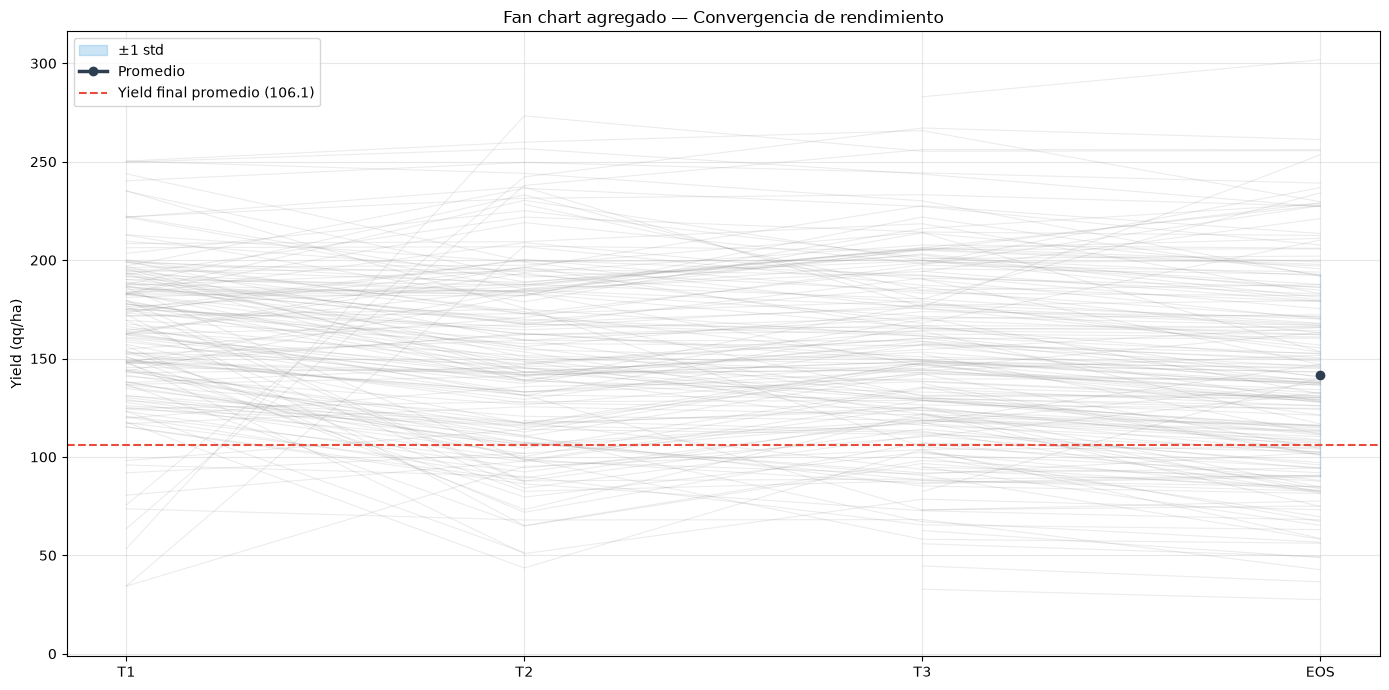

In [22]:
# ── E8. Usar fan chart agregado ──────────────────────────────────────────────
graficar_fan_chart_agregado(df_conv)

---
## F — Tablero resumen

Métricas consolidadas de la validación del módulo predictivo.

In [23]:
# ── F1. Definir: tablero_resumen ──────────────────────────────────────────────
def tablero_resumen(df_conv: pd.DataFrame, df_metricas: pd.DataFrame):
    """
    Imprime tablero resumen con:
    - Bias promedio por ventana
    - RMSE del rendimiento
    - % ciclos con error absoluto < 10%, 20%, 30%
    - Resumen de métricas de curva
    """
    print("=" * 60)
    print("TABLERO RESUMEN — VALIDACIÓN PREDICTIVO")
    print("=" * 60)

    # ── Convergencia ────────────────────────────────────────────────────
    print("\n📊 CONVERGENCIA DE RENDIMIENTO")
    print(f"{'Ventana':<8} {'n':>5} {'Bias':>8} {'RMSE':>8} {'MAE':>8} "
          f"{'<10%':>6} {'<20%':>6} {'<30%':>6}")
    print("-" * 53)

    for v in ["T1", "T2", "T3", "EOS"]:
        col_err = f"error_pct_{v.lower()}"
        sub = df_conv.dropna(subset=[col_err])
        if sub.empty:
            continue
        errs = sub[col_err].abs()
        bias = sub[f"error_{v.lower()}_qq_ha"].mean()
        rmse = np.sqrt((sub[f"error_{v.lower()}_qq_ha"] ** 2).mean())
        mae = sub[f"error_{v.lower()}_qq_ha"].abs().mean()
        pct10 = (errs < 10).mean() * 100
        pct20 = (errs < 20).mean() * 100
        pct30 = (errs < 30).mean() * 100
        print(f"{v:<8} {len(sub):>5} {bias:>8.2f} {rmse:>8.2f} {mae:>8.2f} "
              f"{pct10:>5.0f}% {pct20:>5.0f}% {pct30:>5.0f}%")

    # ── Métricas de curva ───────────────────────────────────────────────
    print("\n📈 MÉTRICAS DE AJUSTE DE CURVAS (EVI)")
    print(f"{'Ventana':<8} {'n':>5} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
    print("-" * 33)
    evi = df_metricas[df_metricas["indice"] == "EVI"]
    for v in ["T1", "T2", "T3"]:
        g = evi[evi["ventana"] == v]
        if g.empty:
            continue
        print(f"{v:<8} {len(g):>5} {g['rmse'].mean():>8.4f} {g['mae'].mean():>8.4f} {g['r2'].mean():>8.4f}")

    print("\n" + "=" * 60)
    print(f"Total ciclos evaluados: {len(df_conv)}")
    print(f"Total predicciones: {len(df_metricas)}")
    ciclos_completos = df_conv.dropna(subset=["yield_t1_qq_ha", "yield_t2_qq_ha",
                                               "yield_t3_qq_ha", "yield_eos_qq_ha"])
    print(f"Ciclos con 4 ventanas completas: {len(ciclos_completos)}")
    print("=" * 60)

In [24]:
# ── F2. Usar ──────────────────────────────────────────────────────────────────
tablero_resumen(df_conv, df_metricas)

TABLERO RESUMEN — VALIDACIÓN PREDICTIVO

📊 CONVERGENCIA DE RENDIMIENTO
Ventana      n     Bias     RMSE      MAE   <10%   <20%   <30%
-----------------------------------------------------
T1         186    53.23    69.98    62.90     5%    11%    20%
T2         164    41.72    48.81    42.12    13%    30%    40%
T3         186    44.19    47.89    44.79     2%     4%    17%
EOS        192    35.44    37.60    35.44     0%     0%    57%

📈 MÉTRICAS DE AJUSTE DE CURVAS (EVI)
Ventana      n     RMSE      MAE       R²
---------------------------------
T1         180   0.1002   0.0803  -1.1405
T2         167   0.0968   0.0798  -5.8799
T3         140   0.0543   0.0445 -21.3251

Total ciclos evaluados: 192
Total predicciones: 972
Ciclos con 4 ventanas completas: 156


---
### Notas
- Todas las celdas son de solo lectura (no persisten en BD).
- Cambia `set_db_path()` en la celda 0b para alternar a BD real.
- Los PDFs se guardan en el directorio de trabajo del notebook.